In [1]:
from google.colab import files

uploaded = files.upload()

Saving walmart.xlsx to walmart.xlsx


In [2]:
import pandas as pd

df = pd.read_excel("walmart.xlsx")

df.head()

,Order ID,Order Date,Ship Date,Customer Name,Country,City,State,Category,Product Name,Sales,Quantity,Profit
0,CA-2013-138688,2013-06-13,2013-06-17,Darrin Van Huff,United States,Los Angeles,California,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,6.8714
1,CA-2011-115812,2011-06-09,2011-06-14,Brosina Hoffman,United States,Los Angeles,California,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,14.1694
2,CA-2011-115812,2011-06-09,2011-06-14,Brosina Hoffman,United States,Los Angeles,California,Art,Newell 322,7.280,4,1.9656
3,CA-2011-115812,2011-06-09,2011-06-14,Brosina Hoffman,United States,Los Angeles,California,Phones,Mitel 5320 IP Phone VoIP phone,907.152,4,90.7152
4,CA-2011-115812,2011-06-09,2011-06-14,Brosina Hoffman,United States,Los Angeles,California,Binders,DXL Angle-View Binders with Locking Rings by S...,18.504,3,5.7825


In [3]:
import pandas as pd

# Load Walmart dataset
df = pd.read_excel("walmart.xlsx")

# Show dataset shape
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Show column names
print("\nColumn Names:")
print(df.columns.tolist())

# Show first 5 rows
df.head()

Rows: 3203
Columns: 12

Column Names:
['Order ID', 'Order Date', 'Ship Date', 'Customer Name', 'Country', 'City', 'State', 'Category', 'Product Name', 'Sales', 'Quantity', 'Profit']


,Order ID,Order Date,Ship Date,Customer Name,Country,City,State,Category,Product Name,Sales,Quantity,Profit
0,CA-2013-138688,2013-06-13,2013-06-17,Darrin Van Huff,United States,Los Angeles,California,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,6.8714
1,CA-2011-115812,2011-06-09,2011-06-14,Brosina Hoffman,United States,Los Angeles,California,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,14.1694
2,CA-2011-115812,2011-06-09,2011-06-14,Brosina Hoffman,United States,Los Angeles,California,Art,Newell 322,7.280,4,1.9656
3,CA-2011-115812,2011-06-09,2011-06-14,Brosina Hoffman,United States,Los Angeles,California,Phones,Mitel 5320 IP Phone VoIP phone,907.152,4,90.7152
4,CA-2011-115812,2011-06-09,2011-06-14,Brosina Hoffman,United States,Los Angeles,California,Binders,DXL Angle-View Binders with Locking Rings by S...,18.504,3,5.7825


In [4]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Check data types
print("\nData Types:")
print(df.dtypes)

Missing Values:
Order ID         0
Order Date       0
Ship Date        0
Customer Name    0
Country          0
City             0
State            0
Category         0
Product Name     0
Sales            0
Quantity         0
Profit           0
dtype: int64

Duplicate Rows:
0

Data Types:
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Customer Name            object
Country                  object
City                     object
State                    object
Category                 object
Product Name             object
Sales                   float64
Quantity                  int64
Profit                  float64
dtype: object


In [5]:
# Remove duplicate rows
df = df.drop_duplicates()

# Convert date columns to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# Check missing values again
print("Missing Values After Cleaning:")
print(df.isnull().sum())

# Check duplicate rows again
print("\nDuplicate Rows After Cleaning:")
print(df.duplicated().sum())

# Check dataset information
print("\nDataset Information:")
df.info()

Missing Values After Cleaning:
Order ID         0
Order Date       0
Ship Date        0
Customer Name    0
Country          0
City             0
State            0
Category         0
Product Name     0
Sales            0
Quantity         0
Profit           0
dtype: int64

Duplicate Rows After Cleaning:
0

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       3203 non-null   object        
 1   Order Date     3203 non-null   datetime64[ns]
 2   Ship Date      3203 non-null   datetime64[ns]
 3   Customer Name  3203 non-null   object        
 4   Country        3203 non-null   object        
 5   City           3203 non-null   object        
 6   State          3203 non-null   object        
 7   Category       3203 non-null   object        
 8   Product Name   3203 non-null   object        
 9  

In [6]:
# Total Sales
total_sales = df["Sales"].sum()

# Total Profit
total_profit = df["Profit"].sum()

# Average Sales per Order
average_sales = df["Sales"].mean()

# Total Quantity Sold
total_quantity = df["Quantity"].sum()

print("===== WALMART SALES ANALYSIS =====")
print(f"Total Sales       : ${total_sales:,.2f}")
print(f"Total Profit      : ${total_profit:,.2f}")
print(f"Average Sales     : ${average_sales:,.2f}")
print(f"Total Quantity    : {total_quantity:,}")

===== WALMART SALES ANALYSIS =====
Total Sales       : $725,457.82
Total Profit      : $108,418.45
Average Sales     : $226.49
Total Quantity    : 12,264


In [7]:
# Calculate total sales for each product
product_sales = df.groupby("Product Name")["Sales"].sum()

# Sort from highest to lowest
top_5_products = product_sales.sort_values(ascending=False).head(5)

print("===== TOP 5 PRODUCTS BY SALES =====")
print(top_5_products)

===== TOP 5 PRODUCTS BY SALES =====
Product Name
Canon imageCLASS 2200 Advanced Copier                                          13999.960
High Speed Automatic Electric Letter Opener                                    13100.240
Global Troy Executive Leather Low-Back Tilter                                  10019.600
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     8134.336
GuestStacker Chair with Chrome Finish Legs                                      8030.016
Name: Sales, dtype: float64


In [8]:
# Calculate total sales by category
category_sales = df.groupby("Category")["Sales"].sum()

# Sort from highest to lowest
category_sales = category_sales.sort_values(ascending=False)

print("===== SALES BY CATEGORY =====")
print(category_sales)

===== SALES BY CATEGORY =====
Category
Chairs         101781.3280
Phones          98684.3520
Tables          84754.5620
Storage         70532.8520
Accessories     61114.1160
Binders         55961.1130
Copiers         49749.2420
Machines        42444.1220
Bookcases       36004.1235
Appliances      30236.3360
Furnishings     30072.7300
Paper           26663.7180
Supplies        18127.1220
Art              9212.0660
Labels           5078.7260
Envelopes        4118.1000
Fasteners         923.2160
Name: Sales, dtype: float64


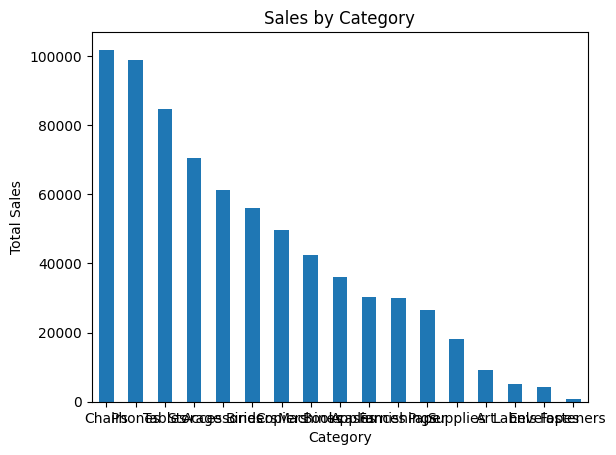

In [9]:
import matplotlib.pyplot as plt

category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

In [10]:
# Calculate total sales by state
state_sales = df.groupby("State")["Sales"].sum()

# Sort from highest to lowest
state_sales = state_sales.sort_values(ascending=False)

print("===== TOP 10 STATES BY SALES =====")
print(state_sales.head(10))

===== TOP 10 STATES BY SALES =====
State
California    457687.6315
Washington    138641.2700
Arizona        35282.0010
Colorado       32108.1180
Oregon         17431.1500
Nevada         16729.1020
Utah           11220.0560
Montana         5589.3520
New Mexico      4783.5220
Idaho           4382.4860
Name: Sales, dtype: float64


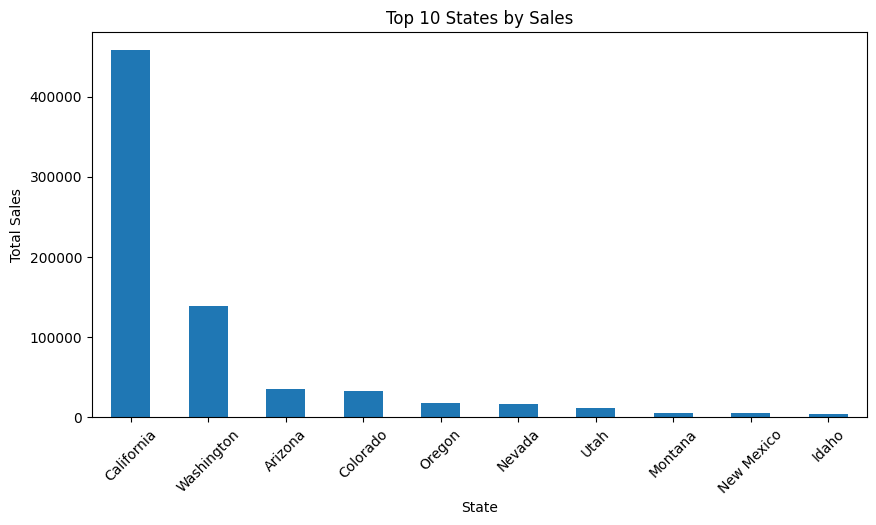

In [11]:
import matplotlib.pyplot as plt

top_10_states = state_sales.head(10)

top_10_states.plot(kind="bar", figsize=(10, 5))

plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [12]:
# Create Year-Month column
df["Year-Month"] = df["Order Date"].dt.to_period("M")

# Calculate monthly sales
monthly_sales = df.groupby("Year-Month")["Sales"].sum()

print("===== MONTHLY SALES =====")
print(monthly_sales)

===== MONTHLY SALES =====
Year-Month
2011-01     2648.0570
2011-02     1348.6220
2011-03    11008.8980
2011-04     9343.4870
2011-05     6570.4380
2011-06     9629.4220
2011-07    21808.5530
2011-08    13248.2310
2011-09    14900.5370
2011-10     8728.7580
2011-11    23191.6245
2011-12    25456.4055
2012-01     6026.7360
2012-02     2004.9140
2012-03    15461.4120
2012-04     9056.0240
2012-05    12042.6555
2012-06     5088.9500
2012-07     7089.8260
2012-08    12548.3590
2012-09    13898.9240
2012-10    14016.6800
2012-11    14548.8960
2012-12    28182.8730
2013-01     3657.8220
2013-02     3100.1620
2013-03    17559.0310
2013-04    10370.1210
2013-05    10806.1350
2013-06    18598.0950
2013-07    14417.7550
2013-08    12680.9800
2013-09    23620.8765
2013-10    13135.3540
2013-11    26412.3450
2013-12    32617.3400
2014-01    12586.0040
2014-02     9814.9170
2014-03    28994.3980
2014-04    13196.9530
2014-05    15901.6460
2014-06    15203.0785
2014-07    21390.7600
2014-08    24196.

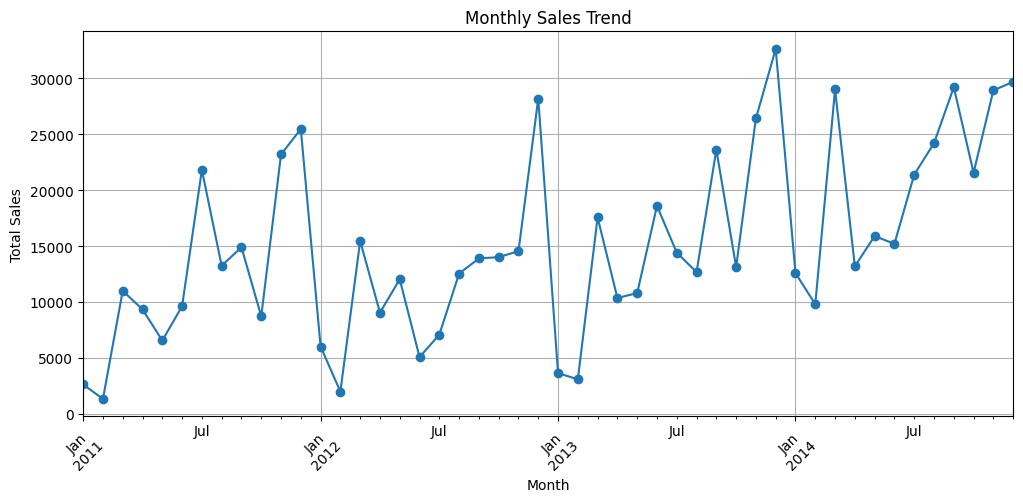

In [13]:
import matplotlib.pyplot as plt

monthly_sales.plot(kind="line", figsize=(12, 5), marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [14]:
# Calculate monthly profit
monthly_profit = df.groupby("Year-Month")["Profit"].sum()

print("===== MONTHLY PROFIT =====")
print(monthly_profit)

===== MONTHLY PROFIT =====
Year-Month
2011-01      20.9733
2011-02     228.8282
2011-03    1534.2273
2011-04    1629.4545
2011-05     873.5640
2011-06    1771.8152
2011-07    1946.6828
2011-08    2560.9044
2011-09    3075.5227
2011-10    1391.2655
2011-11    3151.3107
2011-12    1881.1426
2012-01     600.3079
2012-02     434.1332
2012-03    4243.4035
2012-04    1332.7957
2012-05    1641.1504
2012-06    1034.3461
2012-07      24.2496
2012-08    1238.9703
2012-09    2451.2176
2012-10    1778.4475
2012-11    1750.1860
2012-12    3962.9869
2013-01     644.2454
2013-02     388.3981
2013-03    1210.2185
2013-04     334.3805
2013-05    1506.6791
2013-06    2275.4563
2013-07    2978.7087
2013-08    1249.6678
2013-09    4276.4042
2013-10    1065.1384
2013-11    4795.0301
2013-12    3235.6103
2014-01    3300.0024
2014-02    1648.2299
2014-03    9107.0263
2014-04   -1867.7502
2014-05    2779.0547
2014-06    2648.3827
2014-07    4333.1607
2014-08    6028.0626
2014-09    4891.7154
2014-10    3420.1

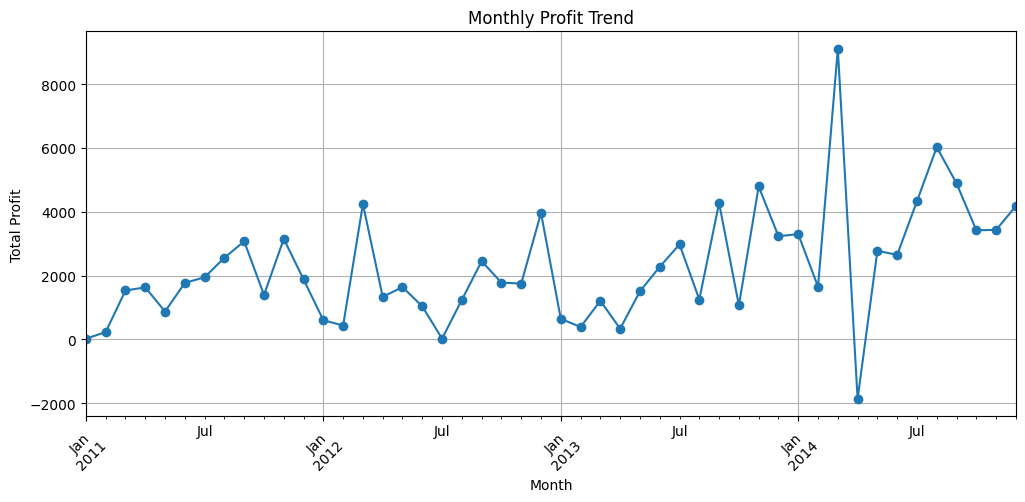

In [15]:
import matplotlib.pyplot as plt

monthly_profit.plot(kind="line", figsize=(12, 5), marker="o")

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [16]:
# Calculate total profit for each product
product_profit = df.groupby("Product Name")["Profit"].sum()

# Sort from highest to lowest
top_5_profitable = product_profit.sort_values(ascending=False).head(5)

print("===== TOP 5 MOST PROFITABLE PRODUCTS =====")
print(top_5_profitable)

===== TOP 5 MOST PROFITABLE PRODUCTS =====
Product Name
Canon imageCLASS 2200 Advanced Copier                                          6719.9808
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    3050.3760
Canon PC1060 Personal Laser Copier                                             2267.9676
Hewlett Packard LaserJet 3310 Copier                                           2183.9636
LogitechÂ Z-906 Speaker sys - home theater - 5.1-CH                            1715.9480
Name: Profit, dtype: float64


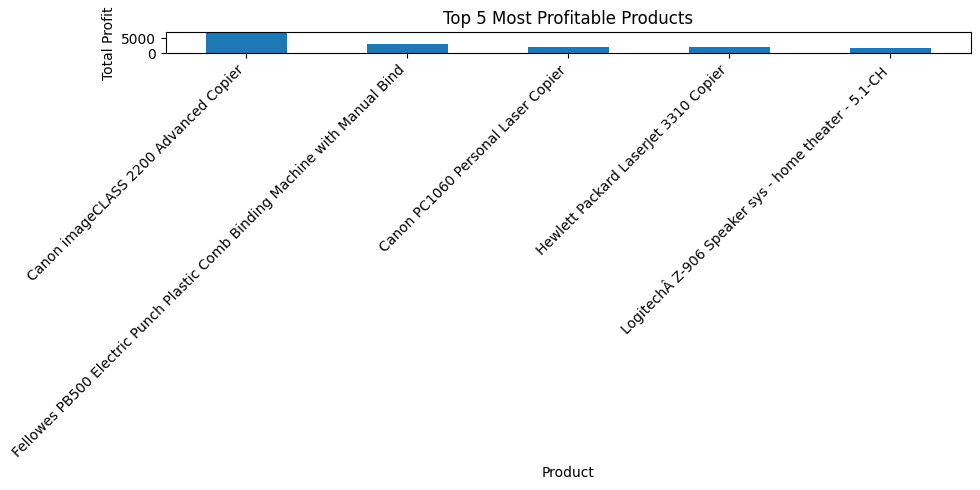

In [17]:
import matplotlib.pyplot as plt

top_5_profitable.plot(kind="bar", figsize=(10, 5))

plt.title("Top 5 Most Profitable Products")
plt.xlabel("Product")
plt.ylabel("Total Profit")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [18]:
# Calculate total profit by category
category_profit = df.groupby("Category")["Profit"].sum()

# Sort from highest to lowest
category_profit = category_profit.sort_values(ascending=False)

print("===== PROFIT BY CATEGORY =====")
print(category_profit)

===== PROFIT BY CATEGORY =====
Category
Copiers        19327.2351
Accessories    16484.5983
Binders        16096.8016
Paper          12119.2364
Phones          9110.7426
Storage         8645.3222
Appliances      8261.2699
Furnishings     7641.2704
Chairs          4027.5843
Art             2374.0970
Labels          2303.1223
Envelopes       1908.7624
Tables          1482.6073
Supplies         626.0465
Fasteners        275.1907
Machines        -618.9264
Bookcases      -1646.5117
Name: Profit, dtype: float64


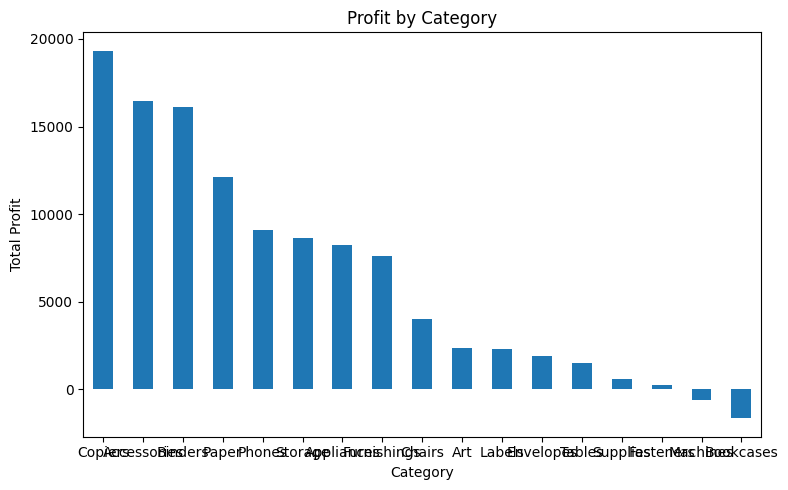

In [19]:
import matplotlib.pyplot as plt

category_profit.plot(kind="bar", figsize=(8, 5))

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [20]:
# Sales and Profit by Category
sales_profit_category = df.groupby("Category")[["Sales", "Profit"]].sum()

print("===== SALES VS PROFIT BY CATEGORY =====")
print(sales_profit_category)

===== SALES VS PROFIT BY CATEGORY =====
                   Sales      Profit
Category                            
Accessories   61114.1160  16484.5983
Appliances    30236.3360   8261.2699
Art            9212.0660   2374.0970
Binders       55961.1130  16096.8016
Bookcases     36004.1235  -1646.5117
Chairs       101781.3280   4027.5843
Copiers       49749.2420  19327.2351
Envelopes      4118.1000   1908.7624
Fasteners       923.2160    275.1907
Furnishings   30072.7300   7641.2704
Labels         5078.7260   2303.1223
Machines      42444.1220   -618.9264
Paper         26663.7180  12119.2364
Phones        98684.3520   9110.7426
Storage       70532.8520   8645.3222
Supplies      18127.1220    626.0465
Tables        84754.5620   1482.6073


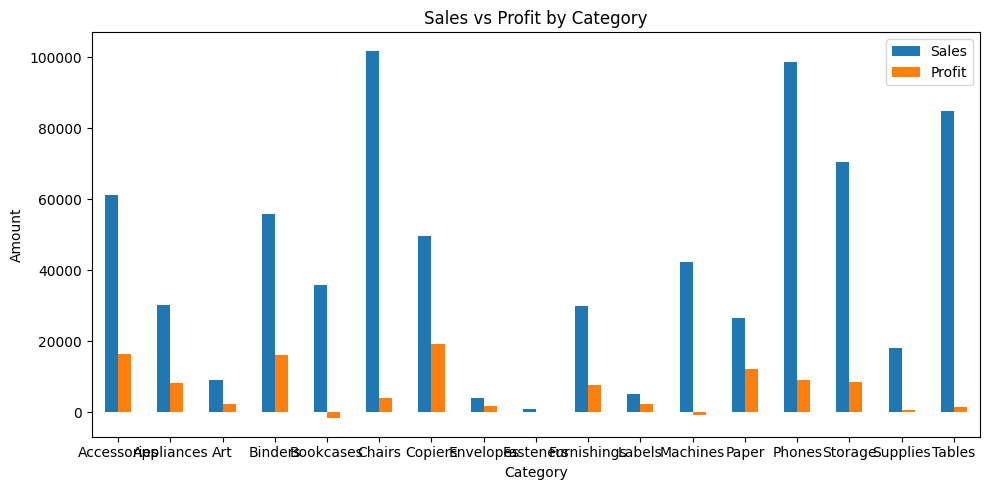

In [21]:
import matplotlib.pyplot as plt

sales_profit_category.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Sales vs Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [22]:
# Calculate total sales for each customer
customer_sales = df.groupby("Customer Name")["Sales"].sum()

# Sort from highest to lowest
top_10_customers = customer_sales.sort_values(ascending=False).head(10)

print("===== TOP 10 CUSTOMERS BY SALES =====")
print(top_10_customers)

===== TOP 10 CUSTOMERS BY SALES =====
Customer Name
Raymond Buch      14345.2760
Ken Lonsdale       8472.3940
Edward Hooks       7447.7700
Jane Waco          7391.5300
Karen Ferguson     7182.7660
Nick Crebassa      6734.2330
Clay Ludtke        6069.6440
Yana Sorensen      5754.1720
Nora Preis         5564.5985
William Brown      5523.0540
Name: Sales, dtype: float64


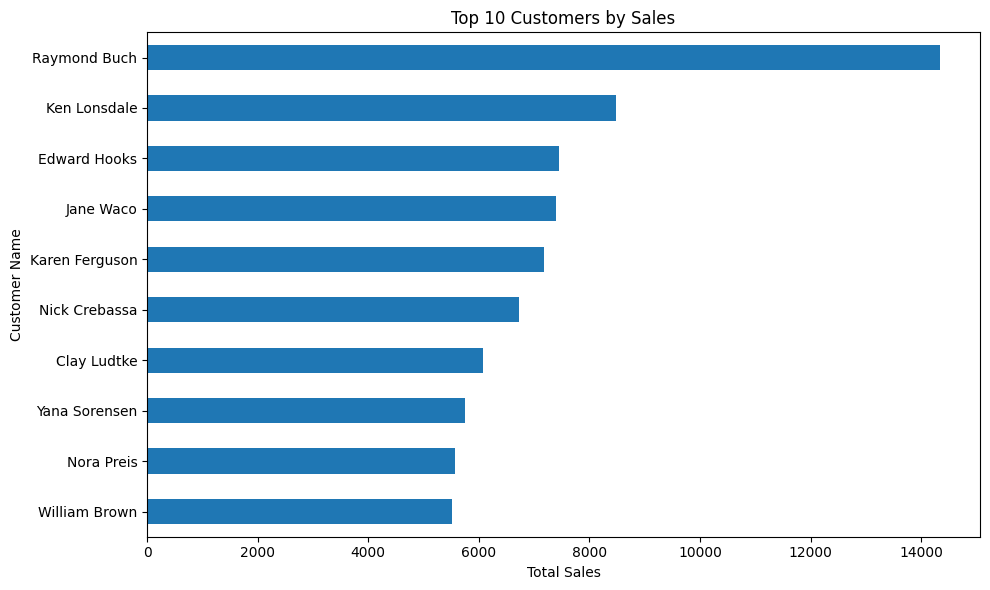

In [23]:
import matplotlib.pyplot as plt

top_10_customers.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Customers by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Customer Name")
plt.tight_layout()
plt.show()

In [24]:
# Calculate total quantity sold for each product
product_quantity = df.groupby("Product Name")["Quantity"].sum()

# Sort from highest to lowest
top_10_quantity = product_quantity.sort_values(ascending=False).head(10)

print("===== TOP 10 PRODUCTS BY QUANTITY SOLD =====")
print(top_10_quantity)

===== TOP 10 PRODUCTS BY QUANTITY SOLD =====
Product Name
Staples                                                                 216
Wilson Jones Clip & Carry Folder Binder Tool for Ring Binders, Clear     32
Cardinal EasyOpen D-Ring Binders                                         31
Eldon Wave Desk Accessories                                              30
LogitechÂ P710e Mobile Speakerphone                                      29
Eldon Shelf Savers Cubes and Bins                                        29
Vinyl Sectional Post Binders                                             29
Memorex Micro Travel Drive 16 GB                                         28
Dana Halogen Swing-Arm Architect Lamp                                    28
GuestStacker Chair with Chrome Finish Legs                               27
Name: Quantity, dtype: int64


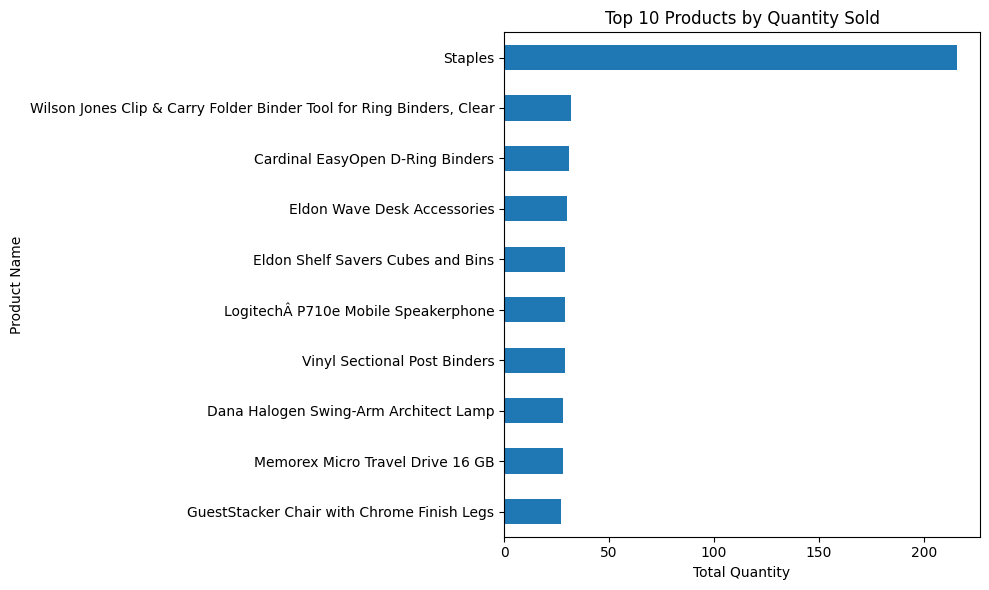

In [25]:
import matplotlib.pyplot as plt

top_10_quantity.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Total Quantity")
plt.ylabel("Product Name")
plt.tight_layout()
plt.show()

In [26]:
# Calculate profit margin for each row
df["Profit Margin"] = (df["Profit"] / df["Sales"]) * 100

# Calculate sales and profit by product
product_analysis = df.groupby("Product Name")[["Sales", "Profit"]].sum()

# Calculate product-level profit margin
product_analysis["Profit Margin"] = (
    product_analysis["Profit"] / product_analysis["Sales"]
) * 100

# Find top 10 products by profit margin
top_10_margin = product_analysis.sort_values(
    "Profit Margin", ascending=False
).head(10)

print("===== TOP 10 PRODUCTS BY PROFIT MARGIN =====")
print(top_10_margin)

===== TOP 10 PRODUCTS BY PROFIT MARGIN =====
                                                     Sales   Profit  \
Product Name                                                          
Xerox 1942                                          293.64  146.820   
OIC Binder Clips                                     64.44   32.220   
Recycled Interoffice Envelopes with String and ...   71.97   35.985   
Prang Dustless Chalk Sticks                          23.52   11.760   
Adams Telephone Message Book w/Frequently-Calle...   55.86   27.930   
Xerox 1916                                          244.70  122.350   
Avery 475                                           133.20   66.600   
Tops Green Bar Computer Printout Paper              146.82   73.410   
White Business Envelopes with Contemporary Seam...   98.46   49.230   
"While you Were Out" Message Book, One Form per...    7.42    3.710   

                                                    Profit Margin  
Product Name                      

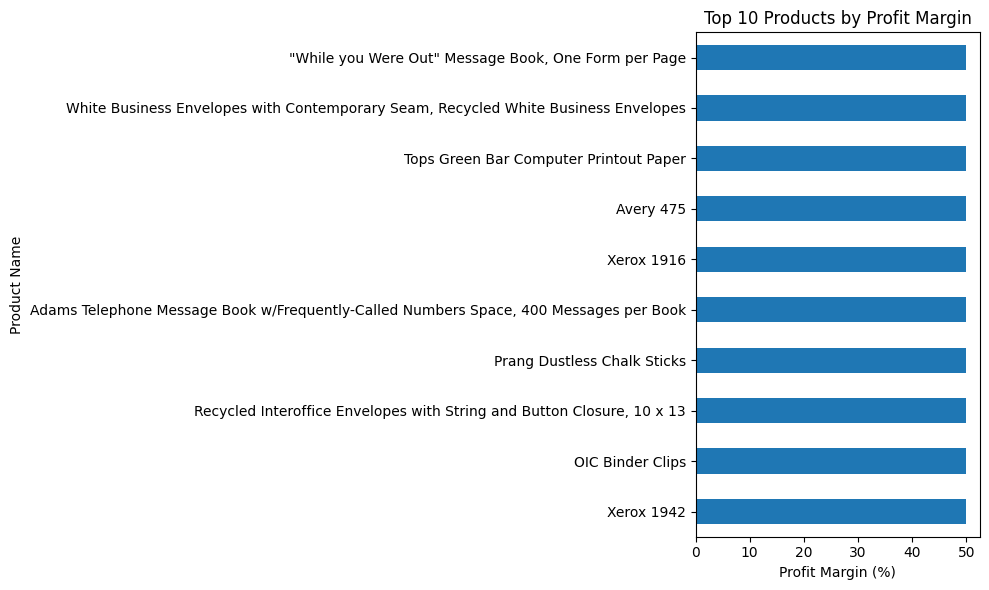

In [27]:
import matplotlib.pyplot as plt

top_10_margin["Profit Margin"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Products by Profit Margin")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Product Name")
plt.tight_layout()
plt.show()

In [28]:
# Extract year from Order Date
df["Year"] = df["Order Date"].dt.year

# Calculate yearly Sales and Profit
yearly_analysis = df.groupby("Year")[["Sales", "Profit"]].sum()

print("===== YEARLY SALES & PROFIT =====")
print(yearly_analysis)

===== YEARLY SALES & PROFIT =====
            Sales      Profit
Year                         
2011  147883.0330  20065.6912
2012  139966.2495  20492.1947
2013  186976.0165  23959.9374
2014  250632.5255  43900.6256


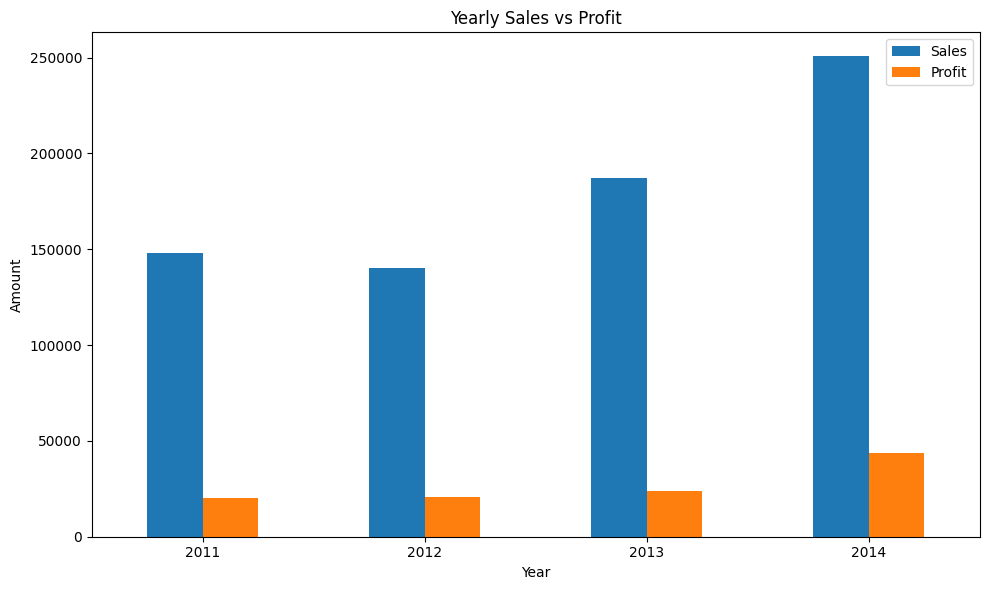

In [29]:
import matplotlib.pyplot as plt

yearly_analysis.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Yearly Sales vs Profit")
plt.xlabel("Year")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [32]:
# Sales and Profit by State
state_analysis = df.groupby("State")[["Sales", "Profit"]].sum()

# Sort by Sales
state_analysis = state_analysis.sort_values(
    "Sales", ascending=False
)

print("===== SALES & PROFIT BY STATE =====")
print(state_analysis.head(10))

===== SALES & PROFIT BY STATE =====
                  Sales      Profit
State                              
California  457687.6315  76381.3871
Washington  138641.2700  33402.6517
Arizona      35282.0010  -3427.9246
Colorado     32108.1180  -6527.8579
Oregon       17431.1500  -1190.4705
Nevada       16729.1020   3316.7659
Utah         11220.0560   2546.5335
Montana       5589.3520   1833.3285
New Mexico    4783.5220   1157.1161
Idaho         4382.4860    826.7231


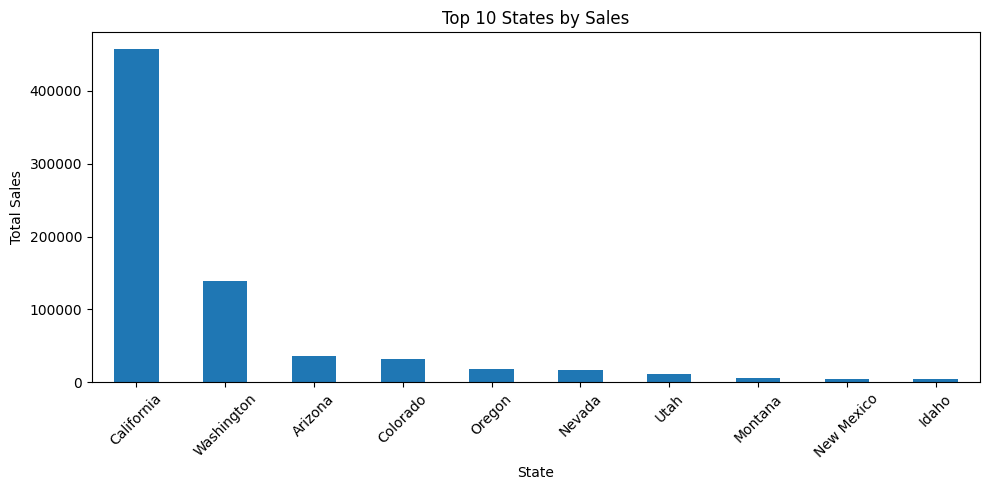

In [33]:
import matplotlib.pyplot as plt

top_10_states = state_analysis.head(10)

top_10_states["Sales"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

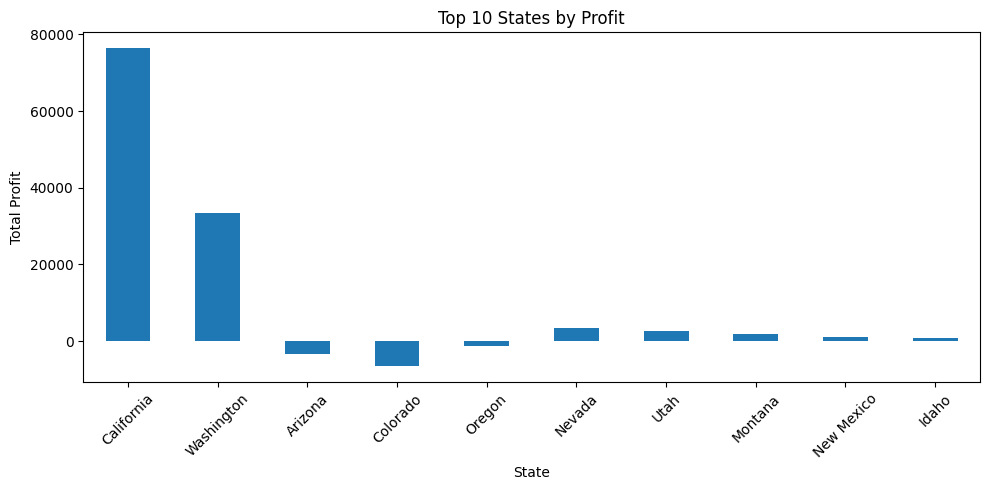

In [34]:
top_10_states["Profit"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top 10 States by Profit")
plt.xlabel("State")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [35]:
# ===== TASK 2 KPI SUMMARY =====

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_quantity = df["Quantity"].sum()
average_sales = df["Sales"].mean()

# Overall profit margin
overall_profit_margin = (total_profit / total_sales) * 100

# Best category by sales
best_category = (
    df.groupby("Category")["Sales"]
      .sum()
      .idxmax()
)

# Best category by profit
best_profit_category = (
    df.groupby("Category")["Profit"]
      .sum()
      .idxmax()
)

# Best state by sales
best_state = (
    df.groupby("State")["Sales"]
      .sum()
      .idxmax()
)

print("=" * 45)
print("       WALMART SALES ANALYSIS - KPI")
print("=" * 45)

print(f"Total Sales          : ${total_sales:,.2f}")
print(f"Total Profit         : ${total_profit:,.2f}")
print(f"Total Quantity Sold  : {total_quantity:,}")
print(f"Average Sales        : ${average_sales:,.2f}")
print(f"Overall Profit Margin: {overall_profit_margin:.2f}%")
print(f"Best Category Sales  : {best_category}")
print(f"Best Category Profit : {best_profit_category}")
print(f"Best State by Sales  : {best_state}")

print("=" * 45)

       WALMART SALES ANALYSIS - KPI
Total Sales          : $725,457.82
Total Profit         : $108,418.45
Total Quantity Sold  : 12,264
Average Sales        : $226.49
Overall Profit Margin: 14.94%
Best Category Sales  : Chairs
Best Category Profit : Copiers
Best State by Sales  : California


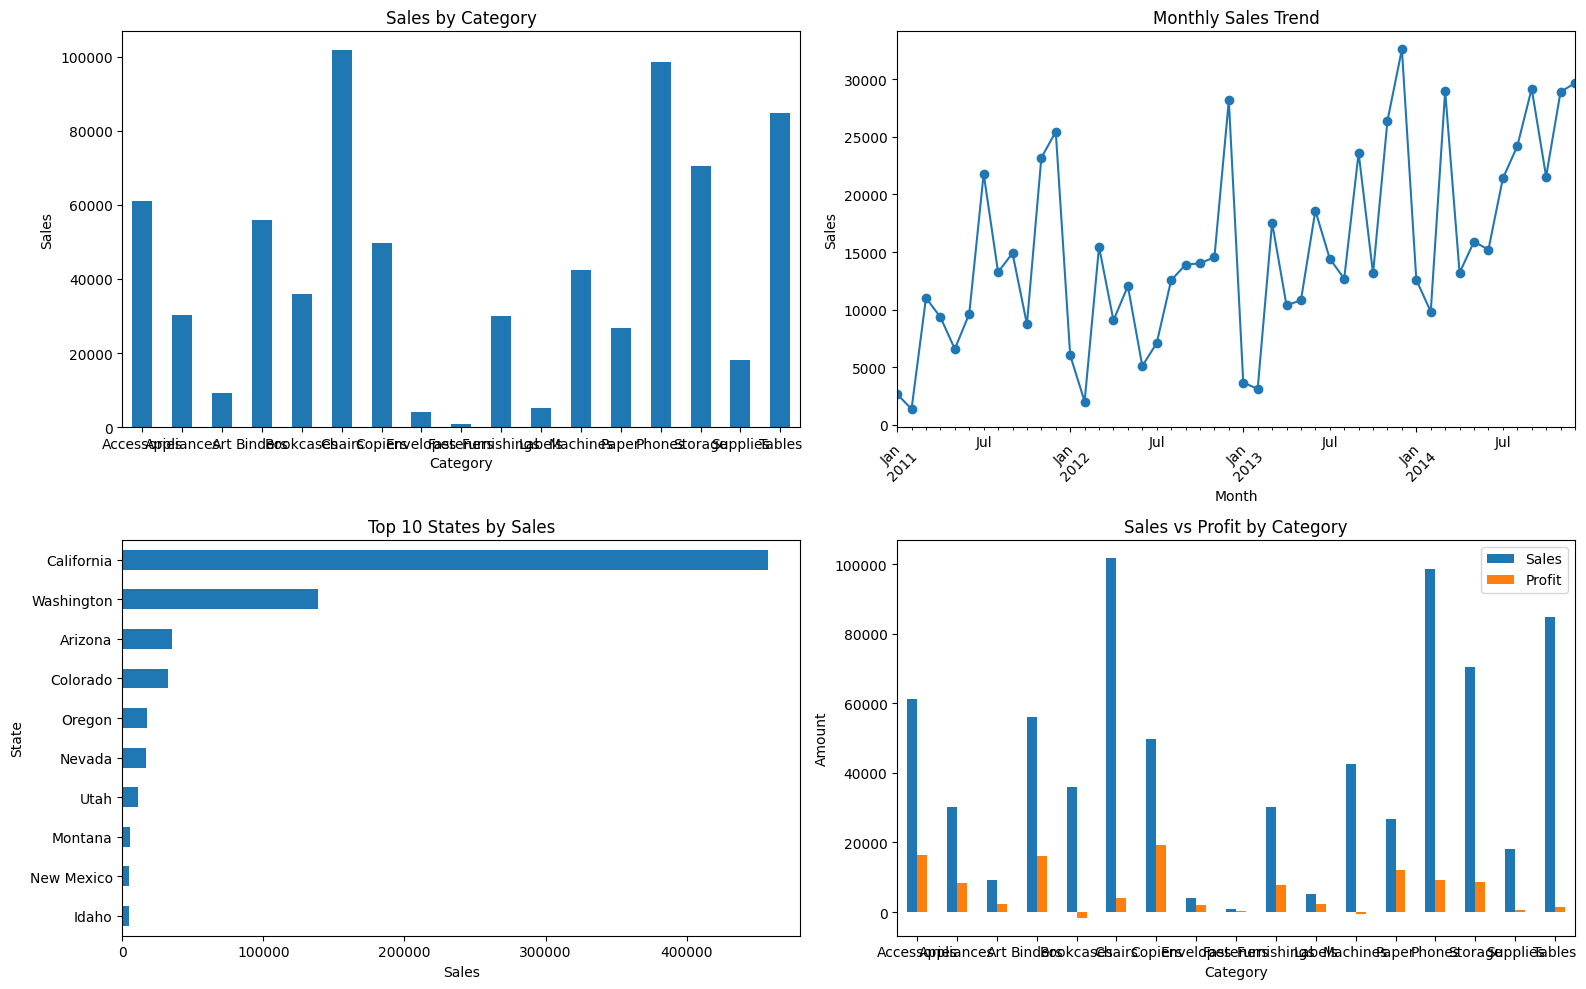

In [36]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Sales by Category
category_sales = df.groupby("Category")["Sales"].sum()
category_sales.plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set_title("Sales by Category")
axes[0, 0].set_xlabel("Category")
axes[0, 0].set_ylabel("Sales")
axes[0, 0].tick_params(axis="x", rotation=0)

# 2. Monthly Sales Trend
monthly_sales = df.groupby("Year-Month")["Sales"].sum()
monthly_sales.plot(kind="line", marker="o", ax=axes[0, 1])
axes[0, 1].set_title("Monthly Sales Trend")
axes[0, 1].set_xlabel("Month")
axes[0, 1].set_ylabel("Sales")
axes[0, 1].tick_params(axis="x", rotation=45)

# 3. Top 10 States
state_sales = df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10)
state_sales.sort_values().plot(kind="barh", ax=axes[1, 0])
axes[1, 0].set_title("Top 10 States by Sales")
axes[1, 0].set_xlabel("Sales")

# 4. Sales vs Profit by Category
category_summary = df.groupby("Category")[["Sales", "Profit"]].sum()
category_summary.plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("Sales vs Profit by Category")
axes[1, 1].set_xlabel("Category")
axes[1, 1].set_ylabel("Amount")
axes[1, 1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

In [37]:
print("===== KEY BUSINESS INSIGHTS =====")

print("""
1. Sales Performance:
   The analysis provides an overview of overall sales performance
   and identifies the major revenue-generating areas.

2. Category Performance:
   Sales and profit vary across categories. The highest-performing
   category should be monitored and supported to maintain growth.

3. Product Performance:
   A small number of products contribute significantly to total
   sales. These products can be considered key revenue drivers.

4. Customer Performance:
   The top customers contribute a significant amount of revenue.
   Understanding their purchasing patterns can support customer
   retention strategies.

5. State Performance:
   Sales differ across states. High-performing states can be
   analyzed to understand the factors driving stronger demand.

6. Monthly Sales Trend:
   Monthly analysis helps identify periods of high and low sales
   and can support better sales planning.

7. Profitability:
   High sales do not always mean high profitability. Profit margin
   should be considered along with sales when evaluating products
   and categories.

8. Recommendation:
   Walmart should focus on high-performing products and categories,
   improve low-margin areas, and use sales trends to support
   inventory and marketing decisions.
""")

===== KEY BUSINESS INSIGHTS =====

1. Sales Performance:
   The analysis provides an overview of overall sales performance
   and identifies the major revenue-generating areas.

2. Category Performance:
   Sales and profit vary across categories. The highest-performing
   category should be monitored and supported to maintain growth.

3. Product Performance:
   A small number of products contribute significantly to total
   sales. These products can be considered key revenue drivers.

4. Customer Performance:
   The top customers contribute a significant amount of revenue.
   Understanding their purchasing patterns can support customer
   retention strategies.

5. State Performance:
   Sales differ across states. High-performing states can be
   analyzed to understand the factors driving stronger demand.

6. Monthly Sales Trend:
   Monthly analysis helps identify periods of high and low sales
   and can support better sales planning.

7. Profitability:
   High sales do not always mean 

In [38]:
# Save cleaned Walmart dataset
df.to_excel("walmart_cleaned.xlsx", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
